In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("../data/cleaned/prices.csv")

In [11]:
df = pd.read_csv("../data/final/final_dataset.csv")
df["month"] = pd.PeriodIndex(df["month"], freq="M")

In [17]:
df["capacity_diff"] = df["battery"].diff()

In [18]:
df.head(5)

,month,battery,summer_capacity,winter_capacity,avg_load,peak_load,load_vol,stress,max_stress_ratio,price_vol,avg_price,spike_freq,intraday_spread,lag_price_vol,capacity_diff
0,2022-01,780.0,780.0,780.0,44910.171458,63525.672430,5378.742713,0.759881,1.000000,14.720376,32.126260,0.002710,45.220645,NaN,NaN
1,2022-02,780.0,780.0,780.0,46526.673345,68954.445628,8009.771825,0.681060,1.000000,31.157071,37.339970,0.025298,68.882857,14.720376,0.0
2,2022-03,809.7,809.7,809.7,40985.760782,56449.246877,4617.997888,0.594389,0.818646,26.708416,35.812608,0.032258,79.872581,31.157071,29.7
3,2022-04,809.7,809.7,809.7,42681.671457,58362.374963,5961.776878,0.618984,0.846390,33.809786,52.339806,0.055556,111.509667,26.708416,0.0
4,2022-05,809.7,809.7,809.7,51558.436924,71632.081429,9463.728621,0.733442,1.000000,97.254997,85.993414,0.180108,203.653871,33.809786,0.0


<Axes: >

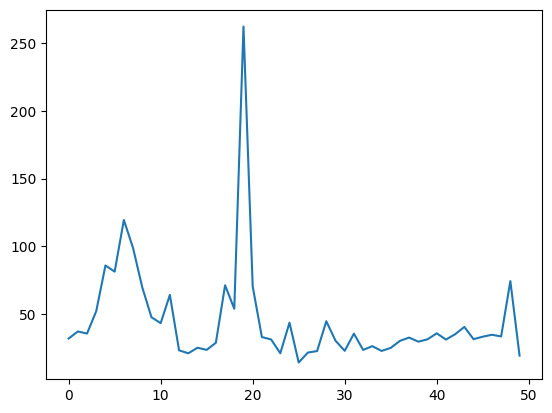

In [22]:
df["avg_price"].plot()

### Model 1: OLS

We begin by standardizing the data and implementing the basic model:
$$
\text{price\_vol}_t
=
\beta_0
+
\beta_1 \,\text{nameplate\_capacity}_t
+
\beta_2 \,\text{peak\_load}_t
+
\beta_3 \,\text{stress}_t
+
\beta_4 \,\text{price\_vol}_{t-1}
+
\varepsilon_t
$$

In [14]:
import statsmodels.api as sm

# sort
df = df.sort_values("month").reset_index(drop=True)

# lag
df["lag_price_vol"] = df["price_vol"].shift(1)

# rename for clarity
df = df.rename(columns={
    "nameplate_capacity": "battery",
    "avg_stress_ratio": "stress"
})

# select variables
model_df = df[["price_vol", "battery", "peak_load", "stress", "lag_price_vol"]].dropna()

# ---------------------------
# STANDARDIZE X VARIABLES
# ---------------------------
X = model_df[["battery", "peak_load", "stress", "lag_price_vol"]].copy()

for col in X.columns:
    X[col] = (X[col] - X[col].mean()) / X[col].std()

# add constant AFTER standardizing
X = sm.add_constant(X)

# dependent variable (unchanged)
y = model_df["price_vol"]

# fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              price_vol   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     3.383
Date:                Thu, 02 Apr 2026   Prob (F-statistic):             0.0169
Time:                        15:12:05   Log-Likelihood:                -288.53
No. Observations:                  49   AIC:                             587.1
Df Residuals:                      44   BIC:                             596.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            63.1899     13.163      4.801